In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [21]:
#Loading the dataset
df = pd.read_excel('electricity_bill_data.xlsx')

print(df.head(10))

   Units_Consumed  Family_Members  AC_Hours_Per_Day  Appliance_Count  \
0             422               6               7.8               17   
1             550               6              10.9                6   
2             311               7               1.1               12   
3             470               2               7.5               25   
4             324               7               0.6               12   
5             459               3               6.9                8   
6             544               2               7.7               23   
7             440               2               7.4                6   
8             625               6              11.1               23   
9             354               3               6.9                7   

   House_Area_sqft  Electricity_Bill  
0             1117           3615.96  
1             2887           4410.28  
2              786           2640.66  
3             1414           4022.63  
4           

In [22]:
#Summary of the dataset

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Units_Consumed    1000 non-null   int64  
 1   Family_Members    1000 non-null   int64  
 2   AC_Hours_Per_Day  1000 non-null   float64
 3   Appliance_Count   1000 non-null   int64  
 4   House_Area_sqft   1000 non-null   int64  
 5   Electricity_Bill  1000 non-null   float64
dtypes: float64(2), int64(4)
memory usage: 47.0 KB


,Units_Consumed,Family_Members,AC_Hours_Per_Day,Appliance_Count,House_Area_sqft,Electricity_Bill
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,448.961000,4.449000,5.974700,17.508000,1765.687000,3735.824150
std,102.997631,2.264625,3.556022,7.413967,734.713132,834.026155
min,132.000000,1.000000,0.000000,5.000000,507.000000,1067.110000
25%,378.000000,2.000000,2.700000,11.000000,1114.750000,3124.145000
50%,444.000000,4.000000,6.000000,17.000000,1804.000000,3681.085000
75%,518.250000,6.000000,9.100000,24.000000,2397.250000,4294.967500
max,746.000000,8.000000,12.000000,30.000000,2999.000000,6103.640000


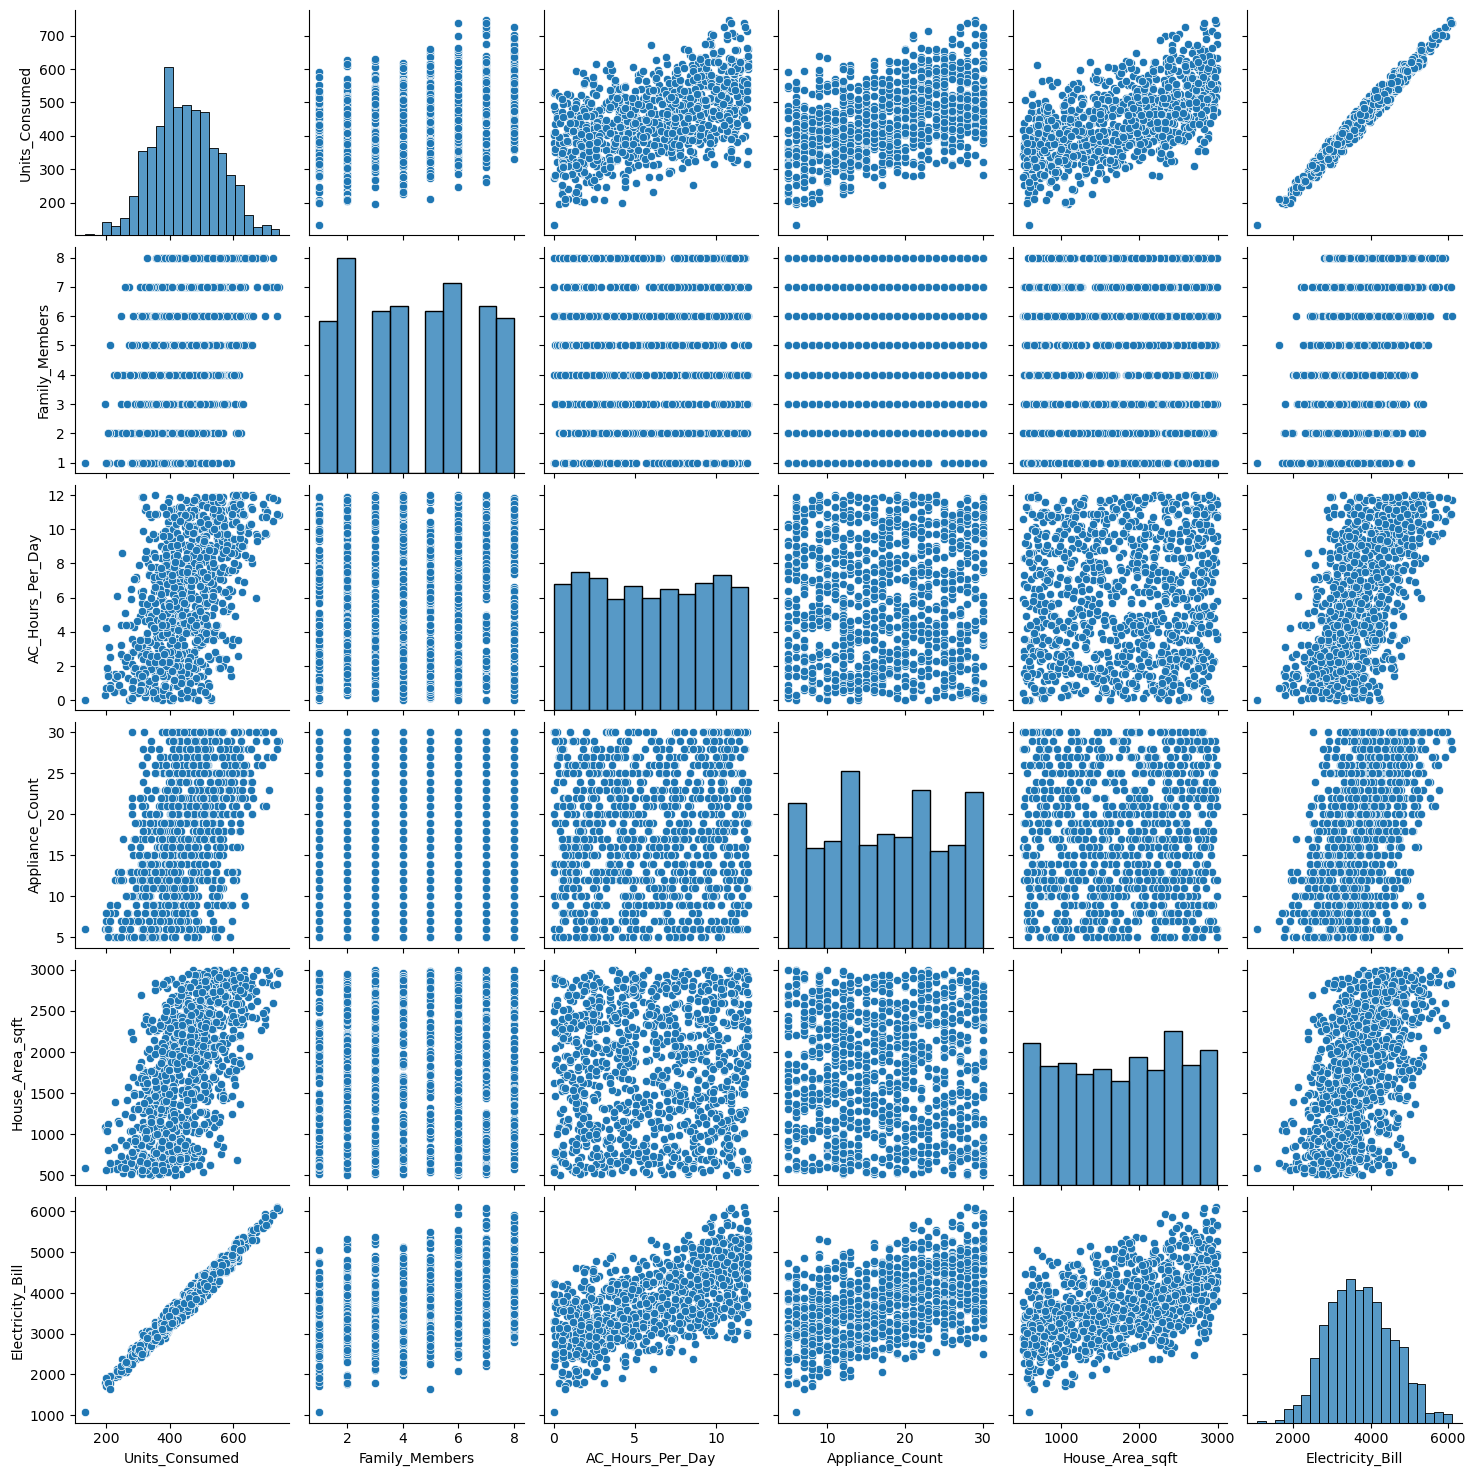

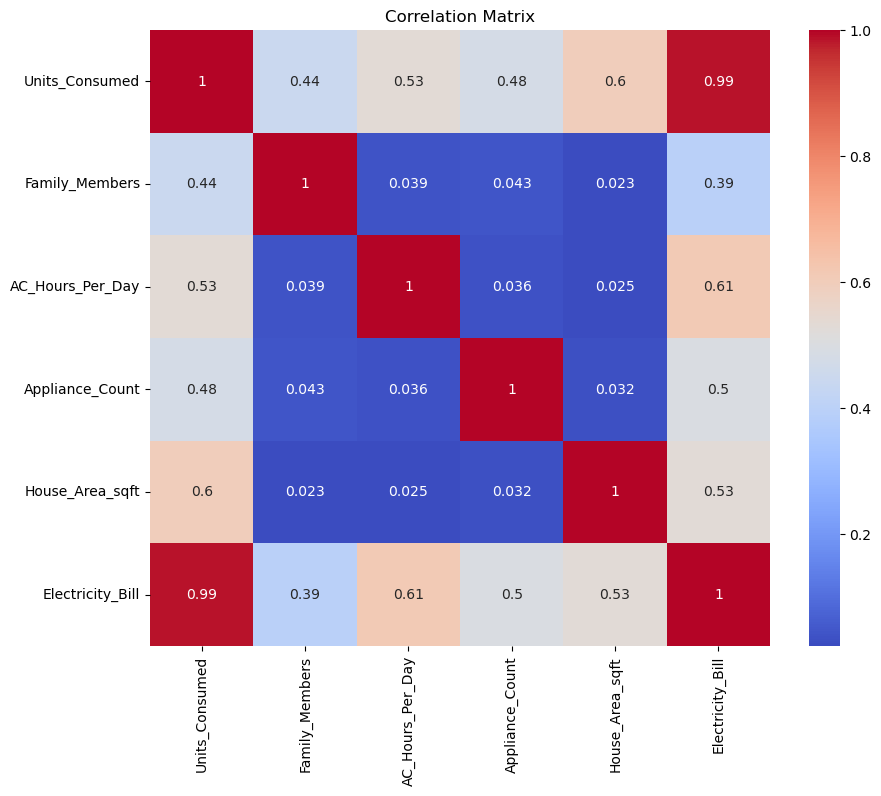

In [23]:
#Data Visualization

sns.pairplot(df)
plt.show()

correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True ,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

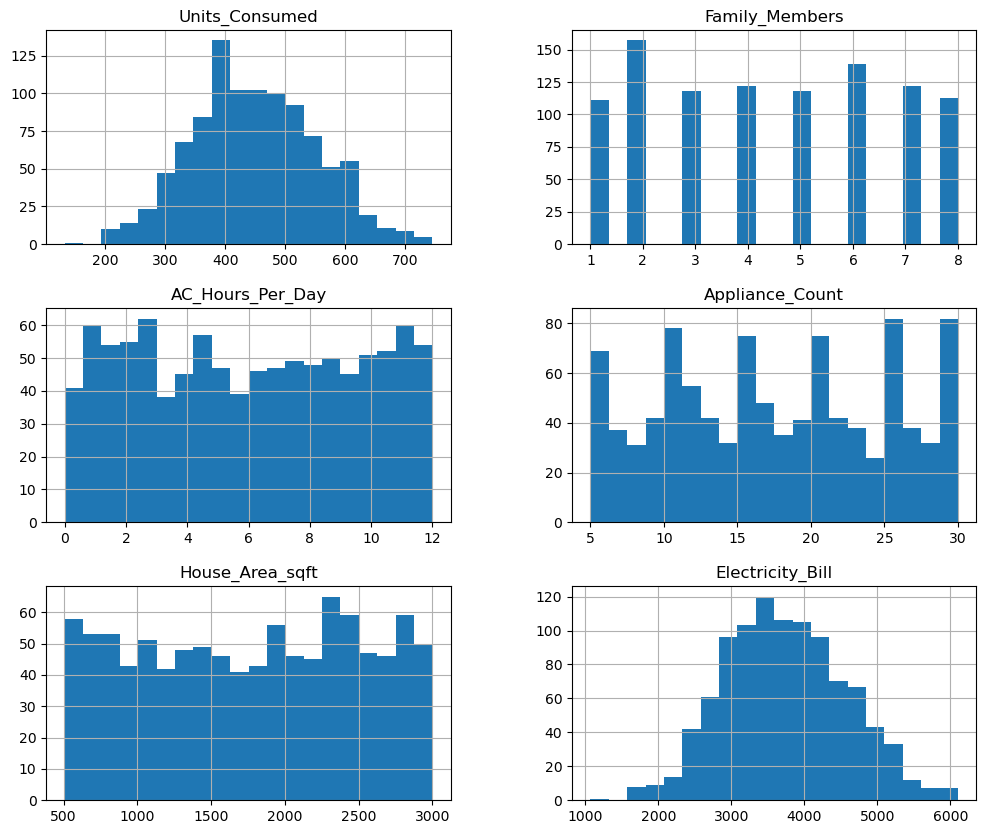

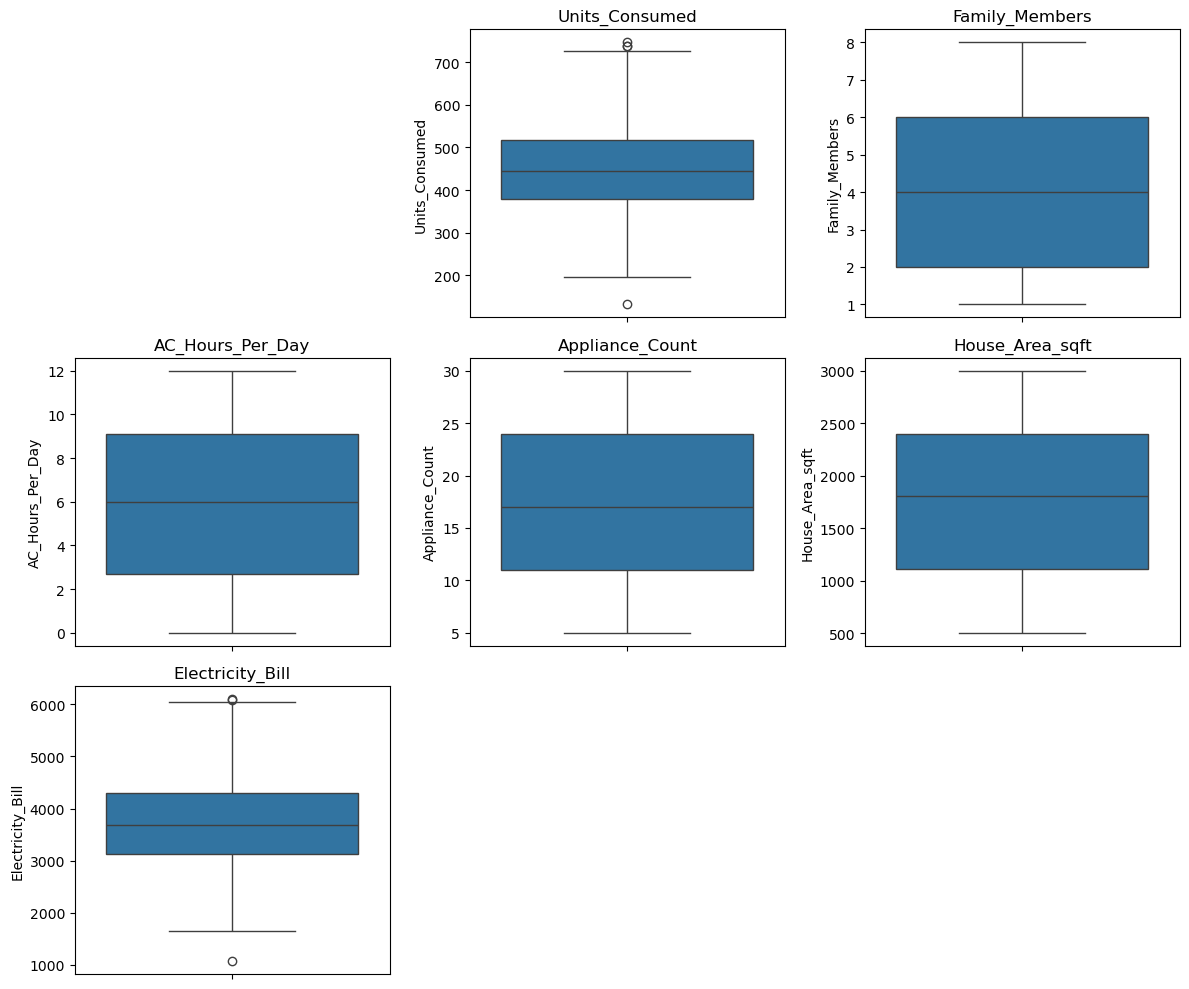

In [24]:
df.hist(figsize=(12,10), bins=20)
plt.show()

plt.figure(figsize=(12,10))
for i, column in enumerate(df.columns, 1):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=df[column])
    plt.title(column)
plt.tight_layout()
plt.show()

**Model Building**

In [25]:
#Define predictors and target variable
X= df[['Units_Consumed',	'Family_Members',	'AC_Hours_Per_Day',	'Appliance_Count',	'House_Area_sqft']]
y=df[['Electricity_Bill']]

In [26]:
#Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [27]:
#Create a linear regression model and fit it to the training data

model= LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
#Make predictions on the test set
y_pred= model.predict(X_test)

#Evaluate the model's performance
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R-squared:", r2_score(y_test, y_pred))


Mean Squared Error: 7114.143346701112
R-squared: 0.9901346808756936


In [29]:
coefficients = pd.DataFrame(model.coef_.T, index=X.columns, columns=['Coefficient'])

print(coefficients)

                  Coefficient
Units_Consumed       6.915959
Family_Members       3.020385
AC_Hours_Per_Day    35.939817
Appliance_Count      9.508724
House_Area_sqft      0.016808


In [30]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values.flatten(),
    "Predicted Price": y_pred.flatten()
})

comparison.head(10)

,Actual Price,Predicted Price
0,4019.47,3912.799295
1,4596.86,4672.509124
2,4737.44,4703.518131
3,3867.00,3994.753895
4,3736.05,3701.739034
5,3358.95,3303.578240
6,2881.76,2860.723542
7,4121.80,4054.594019
8,3506.71,3629.234707
9,3557.47,3590.221268


In [ ]:
import ipywidgets as widgets
from IPython.display import display

units = widgets.FloatText(description='Units:')
family = widgets.IntText(description='Family:')
ac = widgets.FloatText(description='AC Hours:')
appliances = widgets.IntText(description='Appliances:')
area = widgets.FloatText(description='Area:')

display(units, family, ac, appliances, area)
button = widgets.Button(description="Predict Bill")
output = widgets.Output()

display(button, output)

def predict_bill(b):
    with output:
        output.clear_output()

        new_data = pd.DataFrame({
            'Units_Consumed': [units.value],
            'Family_Members': [family.value],
            'AC_Hours_Per_Day': [ac.value],
            'Appliance_Count': [appliances.value],
            'House_Area_sqft': [area.value]
        })

        prediction = model.predict(new_data)

        # If prediction is a scalar or 1D array
        try:
            print(f"Predicted Electricity Bill: ₹{prediction[0]:.2f}")
        except:
            print(f"Predicted Electricity Bill: ₹{prediction[0][0]:.2f}")

button.on_click(predict_bill)

FloatText(value=0.0, description='Units:')

IntText(value=0, description='Family:')

FloatText(value=0.0, description='AC Hours:')

IntText(value=0, description='Appliances:')

FloatText(value=0.0, description='Area:')

Button(description='Predict Bill', style=ButtonStyle())

Output()